In [52]:
#Import necessary packages
import napari
import torch as pt
from sklearn.ensemble import RandomForestClassifier
from skimage.io import imread, imshow
import numpy as np
import napari
import matplotlib.pyplot as plt
from skimage import filters
import numpy as np
from skimage import io, filters
from sklearn.ensemble import RandomForestClassifier



In [53]:
# load the created dataset
output_data_path = "C:/Users/StartKlar/Documents/Msc_Thesis/Data/IDs_NF_kernel_8/"
id = 15
data_subset, label_subset = pt.load(output_data_path + f"ID_{id}_data_label.pt")

#check the shapes of data and labels
print(data_subset.shape
      , label_subset.shape)



(360, 360, 3) (360, 360)


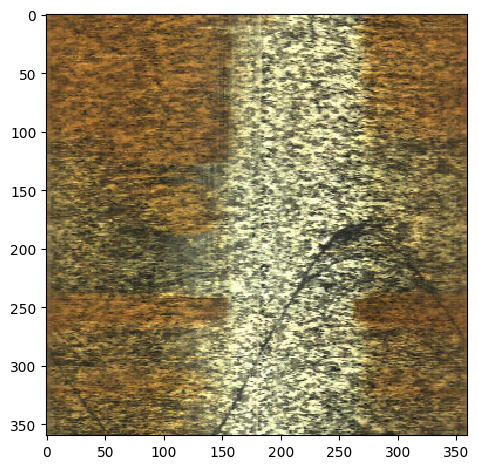

In [54]:
imshow (data_subset)

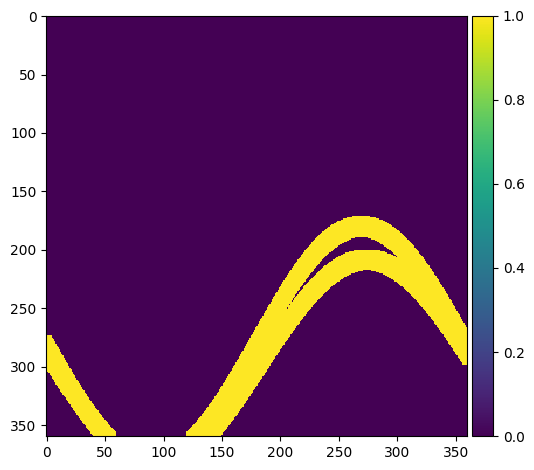

In [55]:
imshow(label_subset)

IndexError: index 7 is out of bounds for axis 0 with size 7

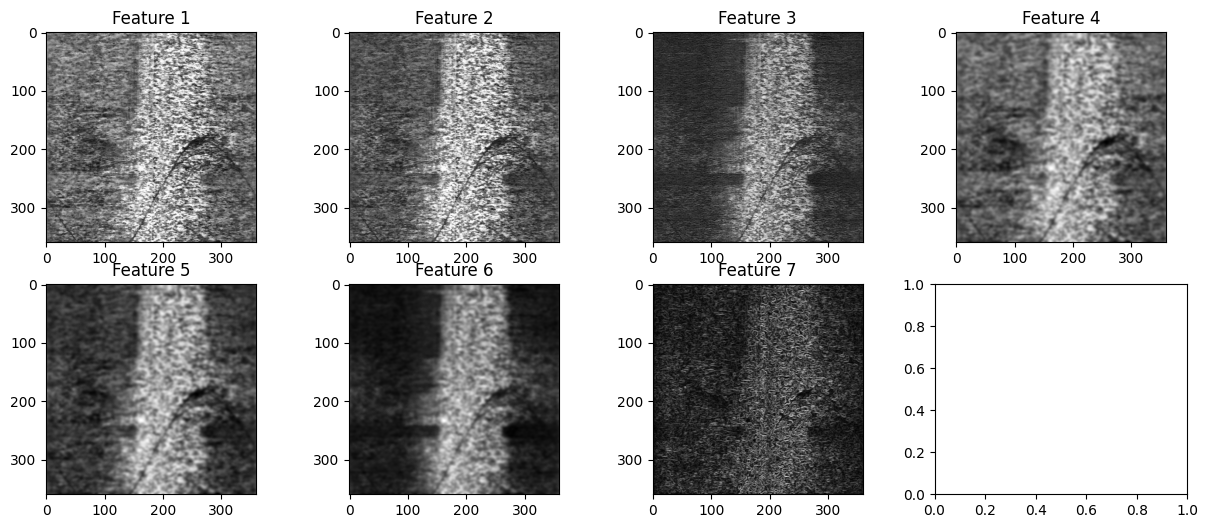

In [69]:

# feature stack for RGB data
# Function to generate feature stack for RGB image
def generate_feature_stack(image):
    # Determine features for RGB image
    blurred = np.zeros_like(image, dtype=np.float64)
    for i in range(image.shape[-1]):
        blurred[:, :, i] = filters.gaussian(image[:, :, i], sigma=2)
    edges = filters.sobel(image[:, :, 0])  # Apply edge detection on one channel (e.g., red channel)

    # Collect features in a stack
    feature_stack = [
        image[:, :, 0],  # Red channel
        image[:, :, 1],  # Green channel
        image[:, :, 2],  # Blue channel
        blurred[:, :, 0],  # Blurred Red channel
        blurred[:, :, 1],  # Blurred Green channel
        blurred[:, :, 2],  # Blurred Blue channel
        edges  # Sobel edge detection
    ]
    
    # Return stack as numpy-array
    return np.asarray(feature_stack)

    
feature_stack = generate_feature_stack(data_subset)

# show feature images
fig, axes = plt.subplots(2, 4, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(feature_stack[i], cmap='gray')
    ax.set_title(f"Feature {i + 1}")

plt.tight_layout()
plt.show()


In [73]:
def format_data(feature_stack, label_subset):
    # Flatten the feature_stack
    X = np.concatenate([feature.reshape(-1, 1) for feature in feature_stack], axis=1)
    
    # Flatten the label_subset
    y = label_subset.ravel()
    
    # Create a mask based on label_subset
    mask = y > 0
    
    # Apply the mask to both X and y
    X = X[mask]
    y = y[mask]

    return X, y

X, y = format_data(feature_stack, label_subset)


In [77]:
# Train a random forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X, y)

RandomForestClassifier(random_state=42)

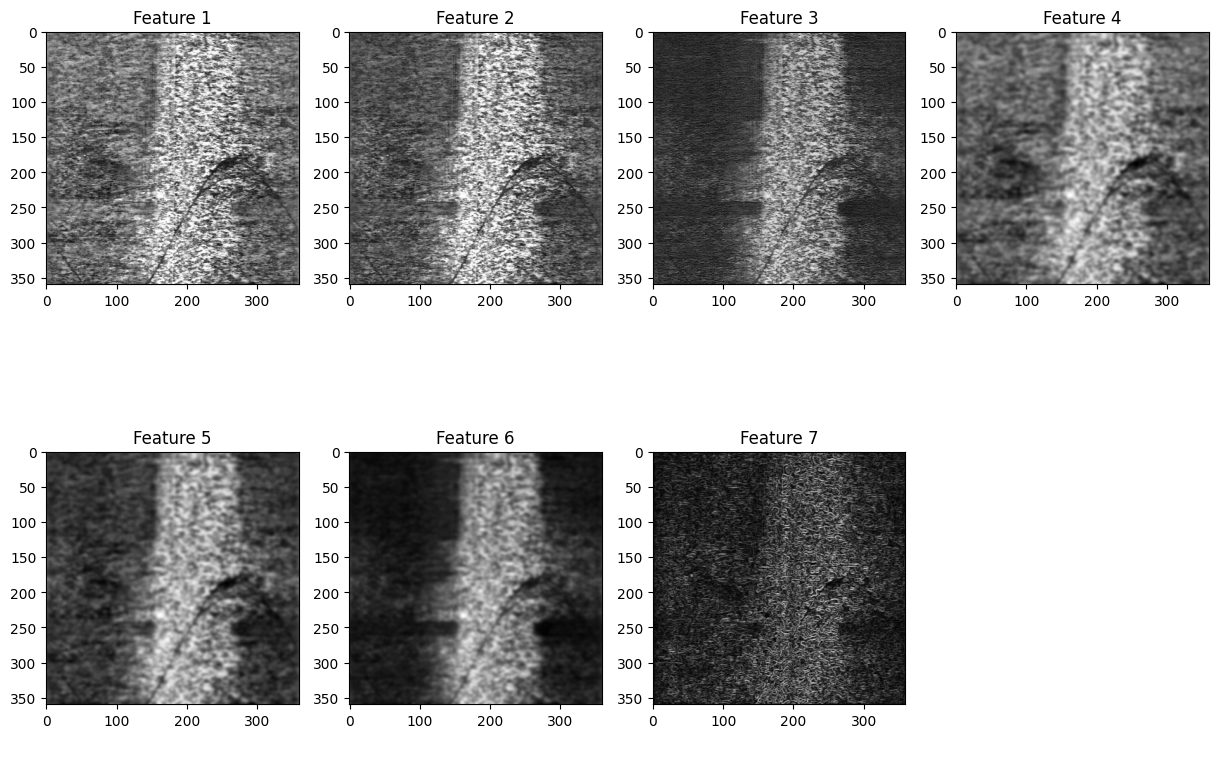

In [83]:
5

In [ ]:
# initialize napari
napari.gui_qt()
viewer = napari.Viewer()


# Here ewe want to try with already trained model

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters
import torch

from deeplogger.model_architectures import UNetOTV
import os


In [94]:
# Load the state dictionary
path_to_model = "C:/Users/StartKlar/Documents/Msc_Thesis/Models/"
model_name = "2D_unet_model04_17only_structures_deep_training_2000epochs-epoch-340.pt"
state_dict = torch.load(path_to_model + model_name, map_location=torch.device('cpu'))

# Define the necessary arguments
in_channels = 3  # Number of input channels (RGB image)
out_channels = 1  # Number of output channels
init_features = 32  # Initial number of features

# Instantiate the model
model = UNetOTV(in_channels=in_channels, out_channels=out_channels, init_features=init_features)

# Load the state dictionary into the model
model.load_state_dict(state_dict)

# Set the model to evaluation mode
model.eval()


UNetOTV(
  (encoder1): Sequential(
    (enc1conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (enc1norm1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (enc1relu1): ReLU(inplace=True)
    (enc1conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (enc1norm2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (enc1relu2): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder2): Sequential(
    (enc2conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (enc2norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (enc2relu1): ReLU(inplace=True)
    (enc2conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (enc2norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

In [95]:

# # Function to generate features for RGB image
# def generate_features_rgb(image):
#     features = []
#     for channel in range(image.shape[-1]):
#         # Apply Gaussian filter to each color channel
#         blurred_channel = filters.gaussian(image[:, :, channel], sigma=2)
#         
#         # Compute edge features using Sobel operator on each color channel
#         edges_channel = filters.sobel(image[:, :, channel])
#         
#         # Append features for each channel
#         features.append(image[:, :, channel])
#         features.append(blurred_channel)
#         features.append(edges_channel)
#     
#     # Stack the features along the channel axis
#     return np.stack(features, axis=-1)

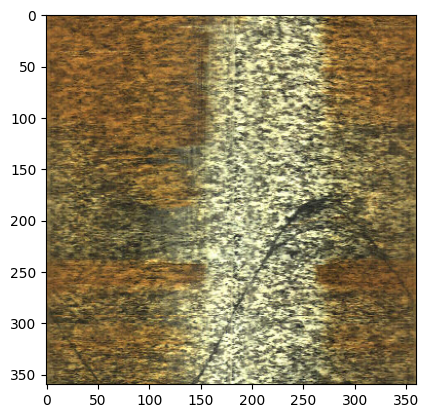

In [106]:
output_data_path = "C:/Users/StartKlar/Documents/Msc_Thesis/Data/IDs_NF_kernel_8/"
id = 15
data_subset, label_subset = torch.load(output_data_path + f"ID_{id}_data_label.pt")

plt.imshow(data_subset)

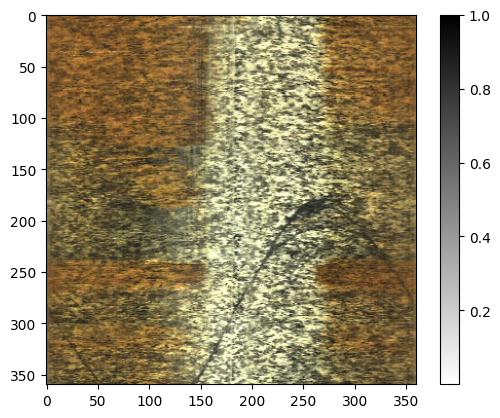

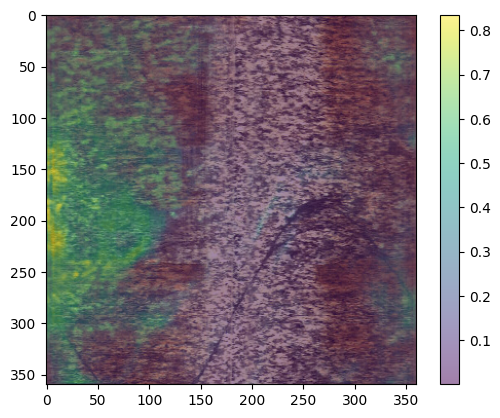

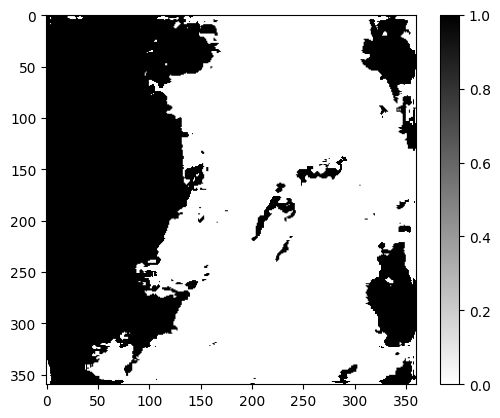

In [97]:

# Load RGB image
X_tensor = torch.from_numpy(data_subset).float()

# Add a batch dimension
X_tensor = X_tensor.unsqueeze(0)

# Predict pixel labels using the trained model
with torch.no_grad():
    predicted_labels_tensor = model(X_tensor)

# Convert predicted labels tensor to numpy array
predicted_labels = predicted_labels_tensor.cpu().numpy()
threshold = 0.10 # Adjust the threshold as needed

# Apply thresholding
predicted_labels_binary = (predicted_labels > threshold).astype(np.uint8)

plt.imshow(data_subset, cmap='binary')  # Assuming a single-channel output
plt.colorbar()
plt.show()

# Visualize the predicted labels
plt.imshow(data_subset)
plt.imshow(predicted_labels, cmap='viridis', alpha = 0.5)  # Change cmap as needed
plt.colorbar()
plt.show()

# Visualize the predicted labels
plt.imshow(predicted_labels_binary, cmap='binary')  # Assuming a single-channel output
plt.colorbar()
plt.show()
# Reshape predicted labels to match the shape of the input image
# predicted_labels_image = predicted_labels.reshape(X_tensor.shape[2:])







In [23]:
import napari
# start napari
viewer = napari.Viewer()

# add image
viewer.add_image(data_subset)

# add an empty labels layer and keet it in a variable
#labels = viewer.add_labels(np.zeros(data_subset.shape).astype(int))


<Image layer 'data_subset' at 0x287230393d0>

In [10]:
viewer

Viewer(camera=Camera(center=(0.0, 162.1535458665151, 254.74733196247152), zoom=0.9886464628259661, angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=False, mouse_zoom=True), cursor=Cursor(position=(0.0, -117.01601695571792, 557.6867751248212), scaled=True, size=10, style=<CursorStyle.CIRCLE: 'circle'>), dims=Dims(ndim=3, ndisplay=2, last_used=0, range=((0.0, 360.0, 1.0), (0.0, 360.0, 1.0), (0.0, 360.0, 1.0)), current_step=(0, 179, 179), order=(0, 1, 2), axis_labels=('0', '1', '2')), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Image layer 'data_subset' at 0x28704fc5c70>, <Labels layer 'Labels' at 0x28704f79880>, <Labels layer 'Labels [1]' at 0x28709ce1df0>], help='use <5> for pan/zoom, use <1> for activate the label eraser, use <3> for activate the fill bucket, use <4> for pick mode', status='', tooltip=Tooltip(visible=False, text=''), theme='dark', title='napari', mouse_over_canvas=False, mouse_move_callbacks=[], mouse_drag_callbacks=[], mouse_double_click_call

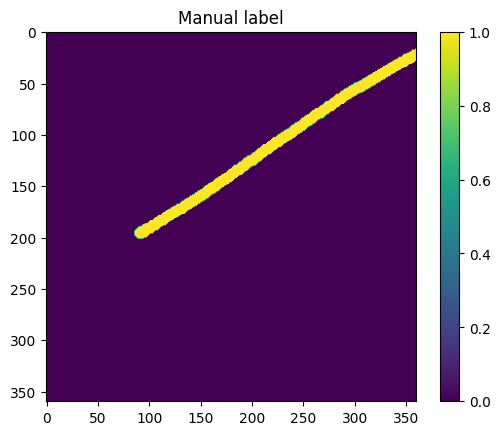

In [24]:

napari.utils.nbscreenshot(viewer)
# Access the data from the 'Labels' layer
manual_annotations = viewer.layers['Labels'].data 

#substract 1 to every item in "manual_annotations"
corrected_label = manual_annotations - 1

# Display the manual annotations using Matplotlib
plt.imshow(corrected_label, vmin=0, vmax=1, cmap='viridis')
plt.colorbar()
plt.title('Manual label')
plt.show()

C:\Users\StartKlar\AppData\Local\Temp\ipykernel_5560\1674466838.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  corrected_label = torch.tensor(corrected_label, dtype=torch.float32)


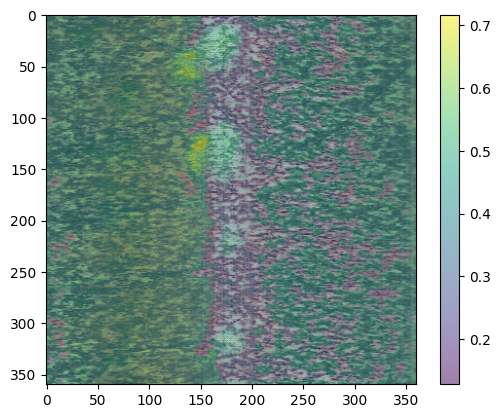

In [113]:
import torch.nn as nn
from torch.nn import BCELoss

# Instantiate your UNetOTV model
model = UNetOTV(in_channels=3, out_channels=1, init_features=32)

# Define your loss function (e.g., CrossEntropyLoss) and optimizer (e.g., Adam)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10


# Training loop 

training_losses = list()
validation_losses = list()
best_validation_loss = float('inf')

transform = Compose([
    RandomHorizontalFlip(p=0.5),
    RandomVerticalFlip(p=0.5)
])  # Set the probability of flipping to 0.5
# loop over the epochs

for epoch in range(max_epochs):
    print('\nEpoch : ' + str(epoch))

    # loop over the mini-batches
    for batch_idx, (image_in, index_mask) in enumerate(training_loader):
        forward_model.train()

        # Apply random horizontal flip to both image and mask
        if random.random() > 0.5:  # Apply flip with 50% probability
            # Apply the same random horizontal flip to both image and mask
            image_in = transform(image_in)
            index_mask = transform(index_mask)

        image_in = image_in.to(device).float()
        index_mask = index_mask.to(device).float()
        index_mask = index_mask.squeeze(0)

        optimizer.zero_grad()
        loss = nn.BCELoss()(forward_model(image_in), index_mask)
        loss.backward()
        training_losses.append(loss.item())
        optimizer.step()
        step_no += 1
        print("Training loss : {}".format(loss.item()))

    if epoch % config["validate_every"] == 0 and epoch > 0:
        torch.cuda.empty_cache()
        forward_model.eval()
        total_loss = 0
        total_batches = 0

        for batch_idx, (image_in, index_mask) in enumerate(validation_loader):
            image_in = image_in.to(device).float()
            index_mask = index_mask.to(device).float()
            index_mask = index_mask.squeeze(0)

            optimizer.zero_grad()
            prediction = forward_model(image_in)
            loss = nn.BCELoss()(prediction, index_mask)
            total_loss += loss.item()
            total_batches += 1

        validation_loss = total_loss / total_batches
        validation_losses.append(validation_loss)
        print("Validation loss : {}".format(validation_loss))

        if validation_loss < best_validation_loss:
            # Save the best model
            best_validation_loss = validation_loss
            print("Saving best model in iteration {}".format(step_no))
            torch.save(forward_model.state_dict(),
                       os.path.join(
                           config["model_dir"] + config["model_name"] + 'BCE_loss_selected_dataset_without_mud_widenedk8_labels' + str(epoch) + '.pt'))
# call the model after the training
model = UNetOTV(in_channels=3, out_channels=1, init_features=32)

output_data_path = "C:/Users/StartKlar/Documents/Msc_Thesis/Data/IDs_NF_kernel_8/"
id = 50
data_subset_test, label_subset_test = torch.load(output_data_path + f"ID_{id}_data_label.pt")

# Load RGB image
X_test = torch.from_numpy(data_subset_test).float()

# Add a batch dimension
X_test = X_test.unsqueeze(0)

# Predict on new data
with torch.no_grad():
    predicted_masks = model(X_test)

# Visualize the results
# You can then visualize the predicted masks similar to how you did with the RandomForestClassifier
predicted_masks = predicted_masks.cpu().numpy()
plt.imshow(data_subset_test)
plt.imshow(predicted_masks, cmap='viridis', alpha=0.5)
plt.colorbar()

# Now, we will try this with a wider dataset and the already trained model :



In [2]:
#import the necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils import data
from deeplogger.model_architectures import UNetOTV
import os
import numpy as np
import matplotlib.pyplot as plt
import napari
from deeplogger.dataloader import Dataset_np as Dataset
from torchvision.transforms import Compose, RandomHorizontalFlip, RandomVerticalFlip
import random
from deeplogger import DATA_DIR, OUTPUT_DIR
import datetime



In [3]:
#Load the pre-trained model
path_to_model = "C:/Users/StartKlar/Documents/Msc_Thesis/Models/"
model_name = "2D_unet_model04_17only_structures_deep_training_2000epochs-epoch-340.pt"
state_dict = torch.load(path_to_model + model_name, map_location=torch.device('cpu'))


In [4]:
#initiate the model, define the criterion and the loss function, put it on evaluation mode
model = UNetOTV(in_channels=3, out_channels=1, init_features=32)
model.load_state_dict(state_dict)
model.eval()

# Define your loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)


In [5]:
#Create a loop for the manual labelling, in which we load each data snippet, predict the labels and then open a napari instance for each image display the image and the predicted labels

# Define the range of IDs
id_range = range(1, 10)

# Define the output directory to save the new datasets


# Loop over files
for id in id_range:
    # Load data and labels from the file
    data_subset, label_subset = torch.load(output_data_path + f"ID_{id}_data_label.pt")

    # Predict labels using the pre-trained model
    with torch.no_grad():
        predicted_labels_tensor = model(torch.from_numpy(data_subset).float().unsqueeze(0))
    predicted_labels = predicted_labels_tensor.cpu().numpy()

    # Convert predicted labels to integer type
    predicted_labels_int = predicted_labels.astype(int)

    # Start Napari viewer
    viewer = napari.Viewer()

    # Add image and predicted labels layers
    viewer.add_image(data_subset)    
    # Add predicted labels layer
    labels_layer = viewer.add_labels(predicted_labels_int)

#### this is an attempt to implement the napari loop in a was which should work
import matplotlib.pyplot as plt

In [1]:


import napari

from deeplogger import DATA_DIR, OUTPUT_DIR

import napari

from glob import glob

import os

from qtpy.QtWidgets import QPushButton

import torch as pt

##load the data and labels from the file

data_path ="C:/Users/StartKlar/Documents/Msc_Thesis/Data/IDs_NF_kernel_3/Sub_file_for_napari_tries"
image_files = glob(data_path +os.sep+ '*label.pt') # looks for all files with this ending in the directory
# data_subset, label_subset = pt.load(output_data_path + f"ID_{id}_data_label.pt")

In [6]:
#define the viewer as napari
viewer = napari.Viewer()
#first,load the data from a buffer

## Here we define necessary functions

def update_image(viewer, image_path):
# Load the new image
        image, label = pt.load(image_path)
# Update or add the image layer

        if 'Image' in viewer.layers:
            viewer.layers['Image'].data = image
        else:
            viewer.add_image(image, name='Image')

# #then, we update the images
# update_image(viewer, image_files)

In [7]:

def save_labels(image, labels_layer, image_path):

# save the image and label together in a pytorch array

    pt.save((image.data, labels_layer.data), image_path.split('.')[0] + '_label_new.pt') # naming convention can be improved




In [ ]:
## start processing the images

def main(image_files):

    viewer = napari.Viewer()

    btn = QPushButton("Next Image")

    viewer.window.add_dock_widget(btn)

    image_iter = iter(image_files)

    current_image_path = next(image_iter)

    update_image(viewer, current_image_path)


    def load_next_image():

        nonlocal current_image_path #changed 'nonlocal' by global, otehrwise there is an error
        save_labels(viewer.layers['Image'], viewer.layers['Labels'], current_image_path)

        try:
            current_image_path = next(image_iter)
            update_image(viewer, current_image_path)

        except StopIteration:
            viewer.close()



    btn.clicked.connect(load_next_image)

    napari.run()

main(image_files)


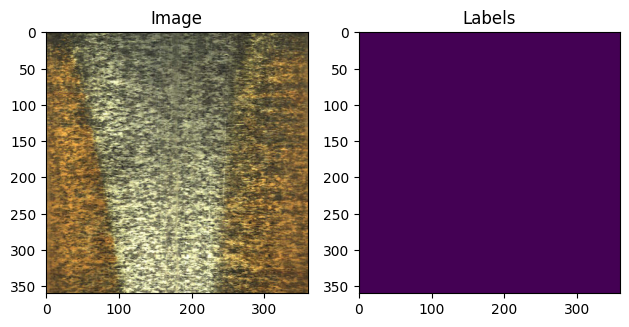

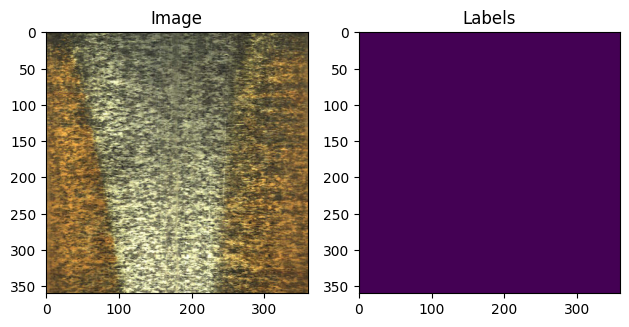

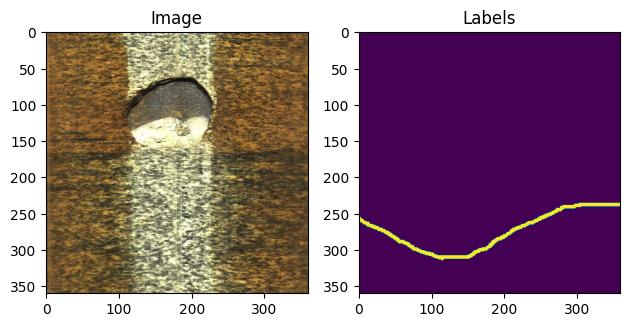

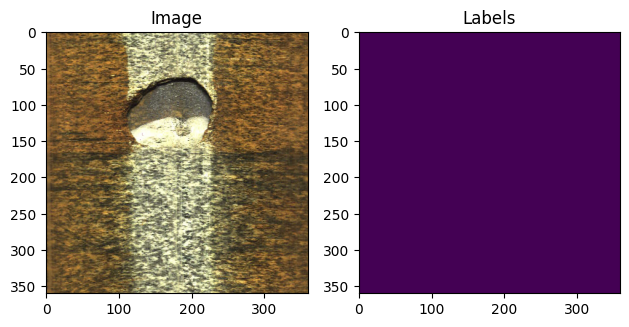

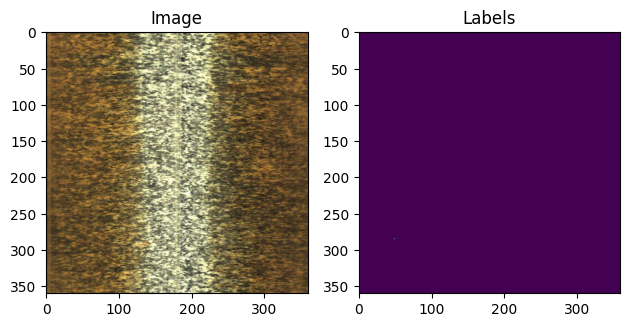

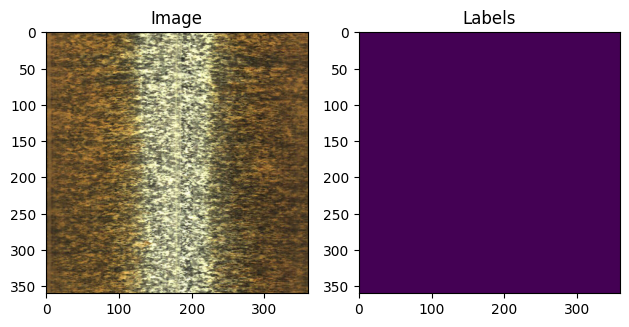

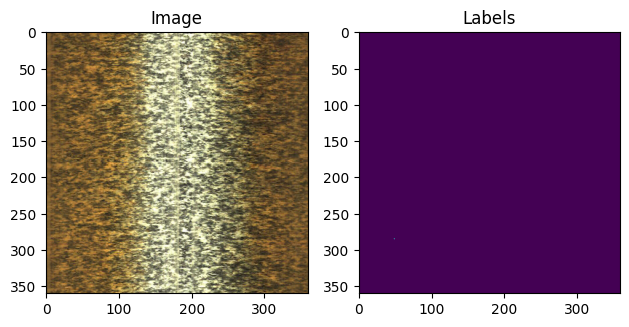

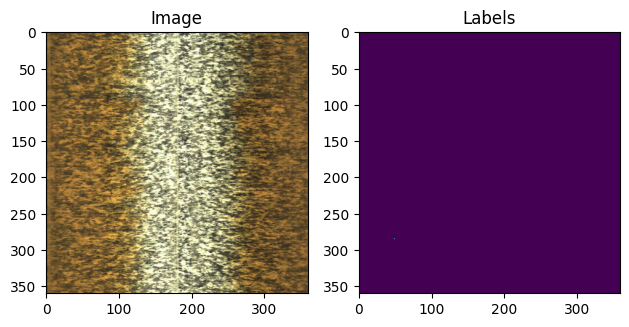

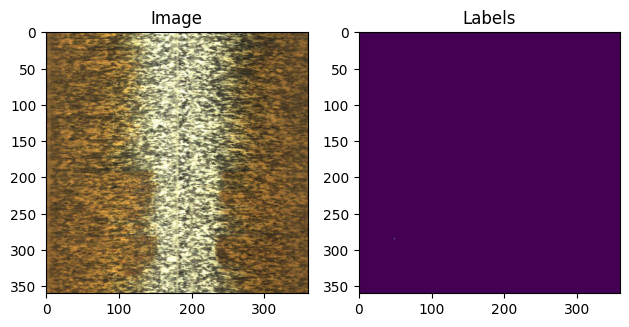

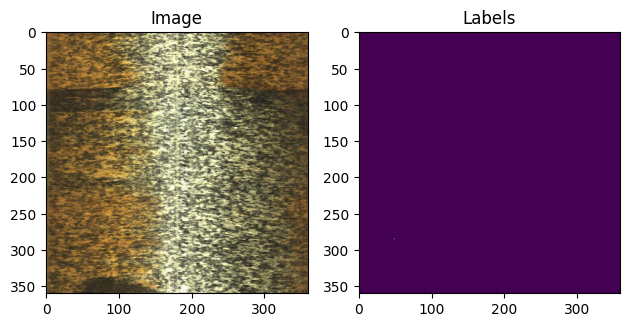

In [16]:
import matplotlib.pyplot as plt
import torch as pt

# Load the saved arrays and plot the labels
label_files = glob(data_path +os.sep + '*_label_new.pt')


for label_file in label_files:
    # Load the saved arrays
    image, labels = pt.load(label_file)

    # Plotting
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(image)
    ax[0].set_title('Image')
    ax[1].imshow(labels)
    ax[1].set_title('Labels')
    
    # Adjust layout to prevent overlapping
    plt.tight_layout()

    # Show the plot
    plt.show()


In [6]:
# Load data and labels from the file
output_data_path = "C:/Users/StartKlar/Documents/Msc_Thesis/Data/IDs_NF_kernel_3/"


id = 1
data_subset, label_subset = torch.load(output_data_path + f"ID_{id}_data_label.pt")

# Predict labels using the pre-trained model
with torch.no_grad():
    predicted_labels_tensor = model(torch.from_numpy(data_subset).float().unsqueeze(0))
predicted_labels = predicted_labels_tensor.cpu().numpy()

# Convert predicted labels to integer type
predicted_labels_int = predicted_labels.astype(int)

# Start Napari viewer
viewer = napari.Viewer()

# Add image and predicted labels layers
viewer.add_image(data_subset)    
# Add predicted labels layer
labels_layer = viewer.add_labels(predicted_labels_int)

In [0]:

    # Message to the user
    print(f"Interact with dataset ID_{id} in the Napari window. Press Enter to save the label layer.")

    # Wait for user interaction before proceeding to the next dataset
    while not input("Press Enter to save the label layer. (Type 'exit' to skip this dataset): "):
        # Get the manually labeled data
        new_labels = labels_layer.data

        # Save the new dataset
        torch.save((data_subset, new_labels), output_data_path+'created_labels_dataset'+ os.sep + f"ID_{id}_data_label_new.pt")
        print(f"New dataset for ID {id} saved.")
        break

    

Interact with dataset ID_1 in the Napari window. Press Enter to save the label layer.


In [ ]:
# Here we use the new dataset to train the model
data_path_new = output_data_path+'created_labels_dataset'+ os.sep

file_IDs = list()

for path in os.listdir(data_path_new):
    full_path = os.path.join(data_path_new, path)
    if os.path.isfile(full_path):
        file_IDs.append(full_path)

new_dataset = Dataset(file_IDs)

# partition the dataset
lengths = [int(np.ceil(len(new_dataset) * 0.8)), int(np.floor(len(new_dataset) * 0.2))]
training_set, validation_set = torch.utils.data.random_split(new_dataset, lengths)
loss_function = nn.BCELoss()
validation_loss = np.array([np.inf])

training_loader = data.DataLoader(training_set, batch_size=20, shuffle=True, drop_last=True)
validation_loader = data.DataLoader(validation_set, batch_size=8, shuffle=True)

step_no = 0
max_acc = 0

#define the device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

#define necessary parameters
date_string = datetime.date.today().strftime("%m_%d")
model_name = '2D_unet_model' + date_string
new_model_directory =
max_epochs = #to define


# Loop over the epochs
for epoch in range(max_epochs):
    print('\nEpoch : ' + str(epoch))

    # Loop over the mini-batches
    for batch_idx, (image_in, index_mask) in enumerate(training_loader):
        model.train()  # Set the model to train mode

        # Apply random horizontal flip to both image and mask
        if random.random() > 0.5:  # Apply flip with 50% probability
            # Apply the same random horizontal flip to both image and mask
            image_in = transform(image_in)
            index_mask = transform(index_mask)

        image_in = image_in.to(device).float()
        index_mask = index_mask.to(device).float()
        index_mask = index_mask.squeeze(0)

        optimizer.zero_grad()
        # Forward pass
        predicted_mask = model(image_in)
        # Compute the loss
        loss = criterion(predicted_mask, index_mask)
        # Backpropagation
        loss.backward()
        optimizer.step()
        # Track training losses
        training_losses.append(loss.item())
        step_no += 1
        print("Training loss : {}".format(loss.item()))

    if epoch % config["validate_every"] == 0 and epoch > 0:
        torch.cuda.empty_cache()
        model.eval()  # Set the model to evaluation mode
        total_loss = 0
        total_batches = 0

        for batch_idx, (image_in, index_mask) in enumerate(validation_loader):
            image_in = image_in.to(device).float()
            index_mask = index_mask.to(device).float()
            index_mask = index_mask.squeeze(0)

            # Forward pass
            prediction = model(image_in)
            # Compute the loss
            loss = criterion(prediction, index_mask)
            total_loss += loss.item()
            total_batches += 1

        validation_loss = total_loss / total_batches
        validation_losses.append(validation_loss)
        print("Validation loss : {}".format(validation_loss))

        if validation_loss < best_validation_loss:
            # Save the best model
            best_validation_loss = validation_loss
            print("Saving best model in iteration {}".format(step_no))
            torch.save(model.state_dict(), os.path.join(config["model_dir"] + model_name + 'BCE_loss_selected_dataset_only_structures_widenedk3_labels_natch_size_20' + str(epoch) + '.pt'))

# Save training and validation losses
config['training_losses'] = training_losses
config["validation_losses"] = validation_losses
